###Question 6: Implement the LeNet-5 architectures using Tensorflow or PyTorch to classify the MNIST dataset. Report the accuracy and training time.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import time

In [ ]:
# Load MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Preprocess
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape to (32x32) for LeNet
x_train = tf.image.resize(x_train[..., tf.newaxis], (32, 32))
x_test = tf.image.resize(x_test[..., tf.newaxis], (32, 32))

# Build LeNet-5 model
model = models.Sequential([
    layers.Conv2D(6, (5,5), activation='tanh', input_shape=(32,32,1)),
    layers.AveragePooling2D(2),

    layers.Conv2D(16, (5,5), activation='tanh'),
    layers.AveragePooling2D(2),

    layers.Flatten(),
    layers.Dense(120, activation='tanh'),
    layers.Dense(84, activation='tanh'),
    layers.Dense(10, activation='softmax')
])

# Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Train time
start_time = time.time()

history = model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.1)

training_time = time.time() - start_time

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9202 - loss: 0.2709 - val_accuracy: 0.9678 - val_loss: 0.1127
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9701 - loss: 0.0975 - val_accuracy: 0.9793 - val_loss: 0.0721
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9802 - loss: 0.0641 - val_accuracy: 0.9828 - val_loss: 0.0584
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9851 - loss: 0.0481 - val_accuracy: 0.9842 - val_loss: 0.0575
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9873 - loss: 0.0393 - val_accuracy: 0.9830 - val_loss: 0.0547


In [ ]:
# Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test)

print(f"\nTest Accuracy: {test_acc*100:.2f}%")
print(f"Training Time: {training_time:.2f} seconds")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9839 - loss: 0.0522

Test Accuracy: 98.39%
Training Time: 20.26 seconds


### Question 7: Use a pre-trained VGG16 model (via transfer learning) on a small custom dataset (e.g., flowers or animals). Replace the top layers and fine-tune the model.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
import tensorflow_datasets as tfds
import time

# Load dataset (flowers)
(dataset_train, dataset_val), dataset_info = tfds.load(
    'tf_flowers',
    split=['train[:80%]', 'train[80%:]'],
    as_supervised=True,
    with_info=True
)

num_classes = dataset_info.features['label'].num_classes

# Preprocessing
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = image / 255.0
    return image, label

train_ds = dataset_train.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = dataset_val.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Load pretrained VGG16 (without top)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# Add new classifier
x = base_model.output
x = layers.Flatten()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=outputs)

# Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train
start = time.time()

history = model.fit(train_ds, validation_data=val_ds, epochs=5)

training_time = time.time() - start

# Fine-tuning (unfreeze top layers)
for layer in base_model.layers[-4:]:
    layer.trainable = True

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(train_ds, validation_data=val_ds, epochs=3)

print(f"\nTraining Time: {training_time:.2f} seconds")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.KM6XP1_3.0.1/tf_flowers-train.tfrecord*...:   0%|   …

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 68s 555ms/step - accuracy: 0.5647 - loss: 1.5071 - val_accuracy: 0.7384 - val_loss: 0.7083
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 228ms/step - accuracy: 0.7452 - loss: 0.6908 - val_accuracy: 0.7943 - val_loss: 0.5208
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 234ms/step - accuracy: 0.7844 - loss: 0.5836 - val_accuracy: 0.8243 - val_loss: 0.4993
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 236ms/step - accuracy: 0.8014 - loss: 0.5183 - val_accuracy: 0.8338 - val_loss: 0.4944
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 232ms/step - accuracy: 0.8396 - loss: 0.4388 - val_accuracy: 0.8365 - val_loss: 0.4622
Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 36s 328ms/step - accuracy: 0.8719 - loss: 0.3379 - val_accuracy: 0.8501 - val_loss: 0.4537
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 268ms/step 

###Question 8: Write a program to visualize the filters and feature maps of the first convolutional layer of AlexNet on an example input image.


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image

In [ ]:
inputs = tf.keras.Input(shape=(224, 224, 3))

x = layers.Conv2D(96, (11,11), strides=4, activation='relu')(inputs)
x = layers.MaxPooling2D((3,3), strides=2)(x)

x = layers.Conv2D(256, (5,5), activation='relu')(x)
x = layers.MaxPooling2D((3,3), strides=2)(x)

model = tf.keras.Model(inputs=inputs, outputs=x)

In [ ]:

first_conv_layer = model.layers[1]   # Conv2D layer

feature_model = tf.keras.Model(
    inputs=model.input,
    outputs=first_conv_layer.output
)

In [ ]:
img_path = "/content/download.jpeg"
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

In [ ]:
# Get feature maps
feature_maps = feature_model.predict(img_array)

# Get filters
filters = first_conv_layer.get_weights()[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step


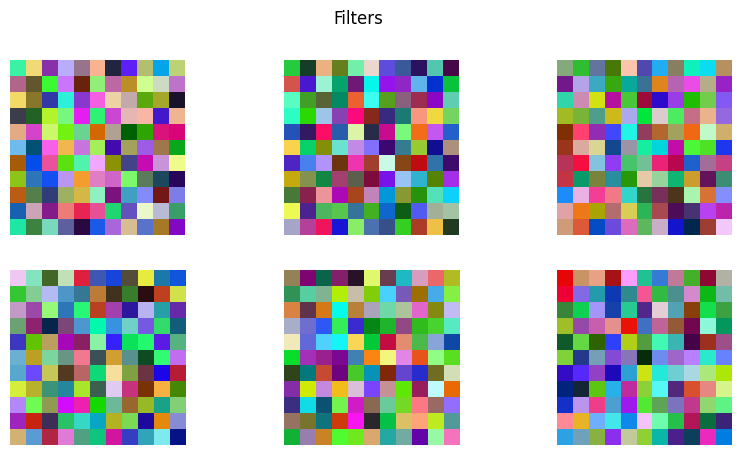

In [ ]:
# Plot filters
plt.figure(figsize=(10,5))
for i in range(6):
    f = filters[:, :, :, i]
    f = (f - f.min()) / (f.max() - f.min() + 1e-5)

    plt.subplot(2,3,i+1)
    plt.imshow(f)
    plt.axis('off')

plt.suptitle("Filters")
plt.show()

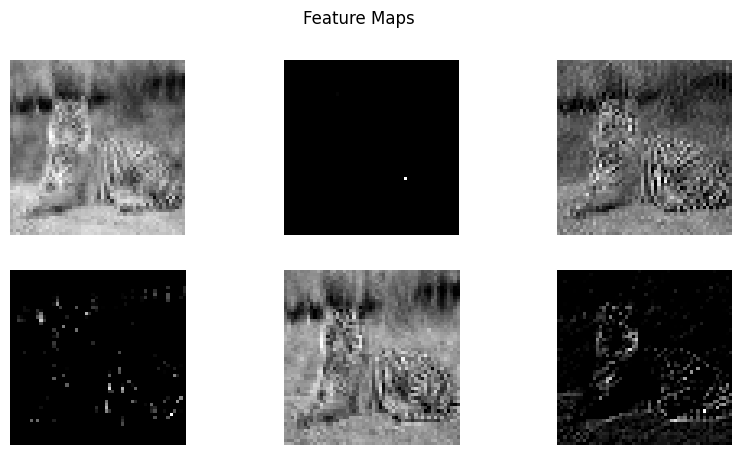

In [ ]:
# Plot feature maps
fm = feature_maps[0]

plt.figure(figsize=(10,5))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(fm[:, :, i], cmap='gray')
    plt.axis('off')

plt.suptitle("Feature Maps")
plt.show()

###Question 9: Train a GoogLeNet (Inception v1) or its variant using a standard dataset like CIFAR-10. Plot the training and validation accuracy over epochs and analyze overfitting or underfitting.


In [50]:
# Load CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Resize
IMG_SIZE = 96
x_train = tf.image.resize(x_train, (IMG_SIZE, IMG_SIZE))
x_test = tf.image.resize(x_test, (IMG_SIZE, IMG_SIZE))

In [51]:
# Split validation
x_val, y_val = x_train[:5000], y_train[:5000]
x_train, y_train = x_train[5000:], y_train[5000:]

# Loading lightweight pretrained model
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [52]:
# Freeze base model
base_model.trainable = False

# Custom classifier
x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(10, activation='softmax')(x)

model = tf.keras.Model(inputs=base_model.input, outputs=outputs)

In [53]:
# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
start = time.time()

history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=5,
    batch_size=32
)

training_time = time.time() - start

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 51s 24ms/step - accuracy: 0.7108 - loss: 0.8376 - val_accuracy: 0.7796 - val_loss: 0.6163
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.7705 - loss: 0.6570 - val_accuracy: 0.7952 - val_loss: 0.5738
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.7895 - loss: 0.6014 - val_accuracy: 0.8010 - val_loss: 0.5654
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.8006 - loss: 0.5656 - val_accuracy: 0.8000 - val_loss: 0.5640
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.8112 - loss: 0.5347 - val_accuracy: 0.8124 - val_loss: 0.5394


In [54]:
print(f"Training Time: {training_time:.2f} sec")

Training Time: 111.03 sec


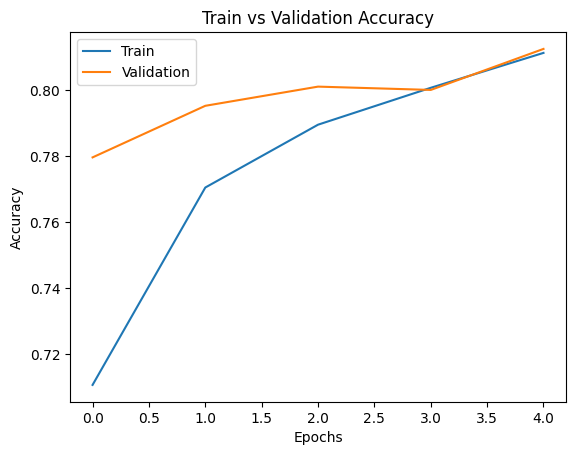

In [55]:
# Plot

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Train vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()